## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales_data = pd.read_csv("train.csv")
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
sales_data.shape

(9800, 18)

In [4]:
# Preprocessing
sales_data["Order Date"] = pd.to_datetime(sales_data["Order Date"], format="%d/%m/%Y")
sales_data["Ship Date"] = pd.to_datetime(sales_data["Ship Date"], format="%d/%m/%Y")

sales_data['Year'] = sales_data['Order Date'].dt.year
sales_data['Month'] = sales_data['Order Date'].dt.month
sales_data['Week Number'] = sales_data['Order Date'].dt.isocalendar().week
sales_data['Day of Week'] = sales_data['Order Date'].dt.day_name()
sales_data['Quarter'] = sales_data['Order Date'].dt.quarter

# Function to extract season
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else: return "Post-Monsoon"
sales_data['Season'] = sales_data['Month'].apply(get_season)

print("Missing Values:\n", sales_data.isnull().sum(),sep="")
print("\nDuplicates Count:", sales_data.duplicated().sum())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Duplicates Count: 0


In [5]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

In [6]:
df_time = sales_data.set_index('Order Date')

# Aggregating dails sales into weekly totals
weekly_sales = df_time['Sales'].resample('W').sum().reset_index()

# Aggregating daily sales into monthly totals (ME-month end frequency) 
monthly_sales = df_time['Sales'].resample('ME').sum().reset_index()


## EDA

In [7]:
category_revenue = sales_data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(f"Highest generating category: {category_revenue.idxmax()}\n")
print(category_revenue)

Highest generating category: Technology

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [8]:
# Total sales per region per year
yearly_region_sales = sales_data.groupby(['Region', 'Year'])['Sales'].sum().unstack()

# Year-over-year percentage change
growth_rates = yearly_region_sales.pct_change(axis=1).dropna(axis=1)

# The region with the lowest standard deviation in its growth rate is the most consistent.
consistency_score = growth_rates.std(axis=1).sort_values()
most_consistent = consistency_score.idxmin()
print(f"Most consistent region: {most_consistent}\n")
print("Standard Deviation of Growth Rates:\n", consistency_score, sep="")

Most consistent region: East

Standard Deviation of Growth Rates:
Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


In [9]:
df = sales_data.copy()
df['Processing Time'] = (df['Ship Date'] - df['Order Date']).dt.days
# Overall average
overall_avg = df['Processing Time'].mean()
print(f"Overall average processing time: {overall_avg:.2f} days")

# Average by region
regional_avg = df.groupby('Region')['Processing Time'].mean().sort_values()
print("\nAverage processing time by region:\n", regional_avg, sep="")

Overall average processing time: 3.96 days

Average processing time by region:
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Processing Time, dtype: float64


In [10]:
# Total sales for each month across all years
monthly_avg_across_years = sales_data.groupby('Month')['Sales'].mean().sort_values(ascending=False)

print("Average Sales by Month (checking for month spikes):")
print(monthly_avg_across_years)

Average Sales by Month (checking for month spikes):
Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64


## Time series analysis

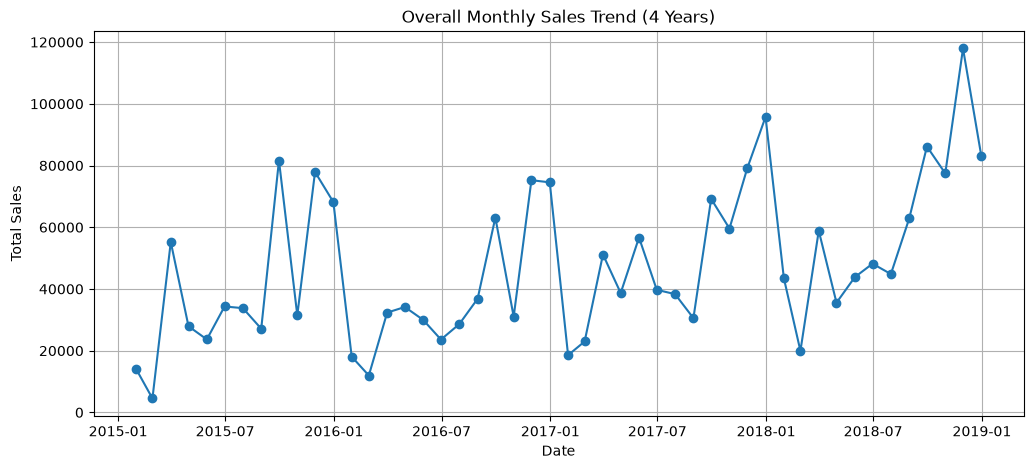

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Plot overall monthly sales trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales['Sales'], marker='o', linestyle='-')
plt.title('Overall Monthly Sales Trend (4 Years)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

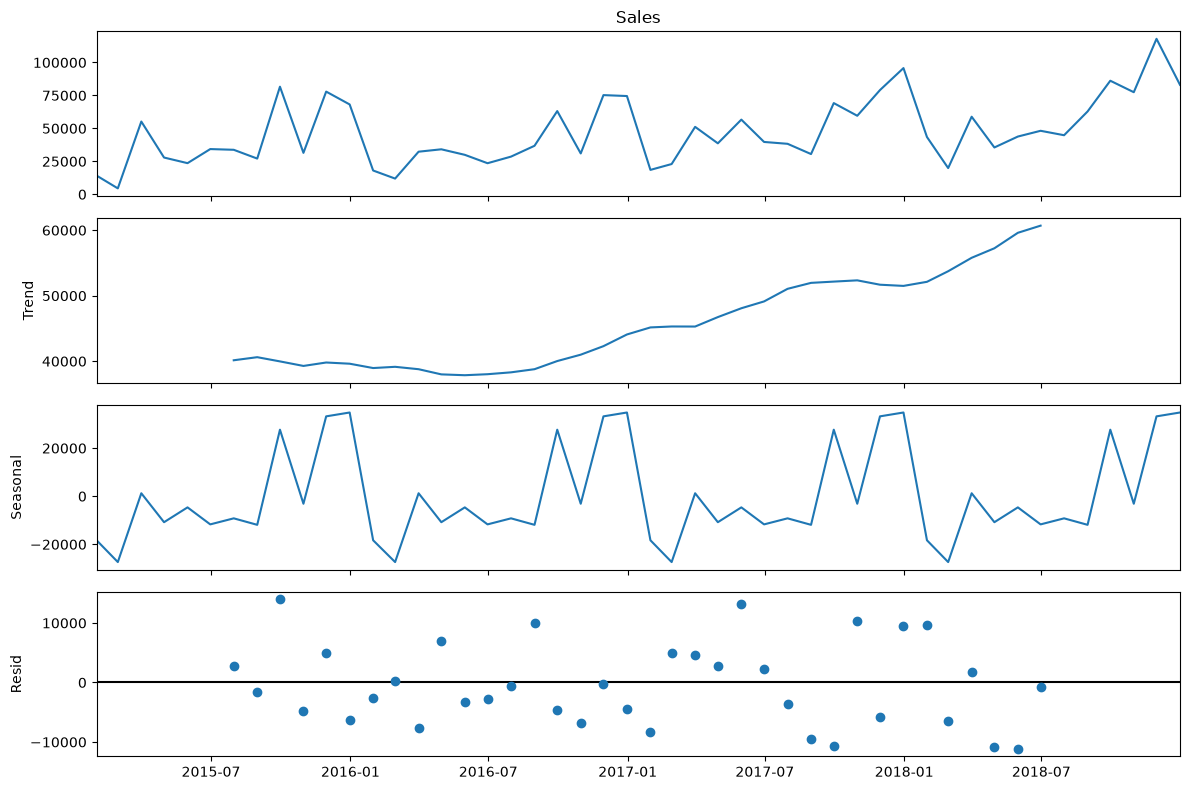

In [ ]:
# Time Series Decomposition
# I use period=12 because the data is monthly and expect a yearly seasonal cycle
decomposition = seasonal_decompose(monthly_sales['Sales'], model='additive', period=12)

# Plot all 4 components clearly on one figure
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

**Insights**
- **Overall Upward Trend**: The trend line shows a steady, long-term increase in sales starting around mid-2016 and continuing through 2018.
- **Strong Seasonality**: Seasonality is very strong and highly predictable, featuring massive, identical recurring spikes and drops at the exact same intervals each year.
- **Peak Residual Noise**: The highest residual noise occurs around late 2015-07, 2016-07, and mid-to-late 2017, where individual data points deviate by more than 10,000 units from the baseline.

In [15]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna())
    
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    if result[1] <= 0.05:
        print("Conclusion: Strong evidence against the null hypothesis, data is stationary.")
    else:
        print("Conclusion: Weak evidence against null hypothesis, data is non-stationary.")

# Test on the original monthly sales
adf_test(monthly_sales['Sales'], title='Original Monthly Sales')

Augmented Dickey-Fuller Test: Original Monthly Sales
ADF Statistic: -4.4161
p-value: 0.0003
Conclusion: Strong evidence against the null hypothesis, data is stationary.


- **Stationarity**: A time series is stationary if its statistical properties like its average (mean) and how much it swings around that average (variance) do not change over time. If the sales are consistently growing year over year (an upward trend), the average is changing, which means the series is non-stationary.
- The ADF test checks for this using hypothesis testing.
  - Null Hypothesis: The series is non-stationary.
  - Alternative Hypothesis: The series is stationary.
  - If the p-value is less than 0.05, we reject the null hypothesis and consider the data stationary.
- As we can see the test clearly shows that data is stationary

## Sales Forecasting

#### Base Models

In [ ]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

# Naive, HistoricAverage, SeasonalNaive, WindowAverage

#### SARIMA